In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
image_path = 'test.jpg'
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img.shape

(312, 252, 3)

In [3]:
h, w = img.shape[:2]
screen_w, screen_h = 1000, 1000

sx, sy = 3, 3
S = np.array([[sx, 0], [0, sy]], dtype=np.float64)

img_c = np.array([w / 2, h / 2])
screen_c = np.array([screen_w / 2, screen_h / 2])
t = screen_c - S @ img_c

M = np.hstack([S, t.reshape(2, 1)])
scaled = cv2.warpAffine(img, M, (screen_w, screen_h))
print('translation:', t)
print('scaled size:', w * sx, h * sy)

translation: [122.  32.]
scaled size: 756 936


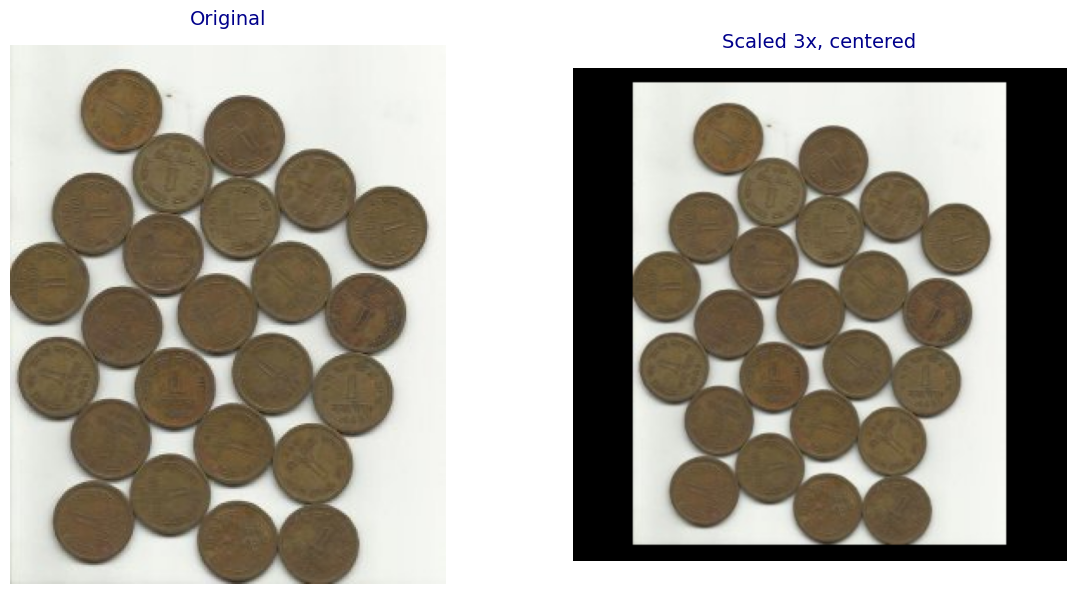

In [4]:
panels = [('Original', img), ('Scaled 3x, centered', scaled)]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

In [5]:
os.makedirs('output', exist_ok=True)
cv2.imwrite('output/task1_scaled.png', cv2.cvtColor(scaled, cv2.COLOR_RGB2BGR))

True

Scaling matrix is [[3, 0], [0, 3]]. Scaling happens about the origin (top left) so if I only apply it the fingerprint grows towards the bottom right and drifts off center.

To keep it centered the image center has to land on the screen center after scaling. S @ img_c + t = screen_c so t = screen_c - S @ img_c. That t goes in the third column, which is why the 2x2 matrix becomes a 2x3 one. Here t = (122, 32), so the scaled image is pushed a bit right and down from the origin and sits in the middle of the 1000x1000 screen.